# MSA 2026 Phase 2 - Part 1

# Part 1 - Analysis and Preprocessing
## Dataset Chosen: W Stores
>> W Stores contains three CSVs (sales, features, stores) that will be merged.


In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler


In [79]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


MERGING 3 CSV INTO SINGLE DATA FRAME FOR EASIER DATA ANALYSIS

In [80]:
# Load all three W Stores files
w_sales    = pd.read_csv('/content/drive/MyDrive/MSA_Phase2/W_Stores/sales.csv')
w_features = pd.read_csv('/content/drive/MyDrive/MSA_Phase2/W_Stores/features.csv')
w_stores   = pd.read_csv('/content/drive/MyDrive/MSA_Phase2/W_Stores/stores.csv')

# Merge on Store column; features also has Date so merge on both
w_df = w_sales.merge(w_stores, on='Store', how='left')
w_df = w_df.merge(w_features, on=['Store', 'Date'], how='left')

## 1. Finding all variables and understanding them

In [81]:
# Printing the 3 separate files to understand the data structure and variables
print("sales.csv — first 10 rows:")
display(w_sales.head(10))

print("\nfeatures.csv — first 10 rows:")
display(w_features.head(10))

print("\nstores.csv — first 10 rows:")
display(w_stores.head(10))

sales.csv — first 10 rows:


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False
5,1,1,2010-03-12,21043.39,False
6,1,1,2010-03-19,22136.64,False
7,1,1,2010-03-26,26229.21,False
8,1,1,2010-04-02,57258.43,False
9,1,1,2010-04-09,42960.91,False



features.csv — first 10 rows:


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False
5,1,2010-03-12,57.79,2.667,NaN,NaN,NaN,NaN,NaN,211.380643,8.106,False
6,1,2010-03-19,54.58,2.720,NaN,NaN,NaN,NaN,NaN,211.215635,8.106,False
7,1,2010-03-26,51.45,2.732,NaN,NaN,NaN,NaN,NaN,211.018042,8.106,False
8,1,2010-04-02,62.27,2.719,NaN,NaN,NaN,NaN,NaN,210.820450,7.808,False
9,1,2010-04-09,65.86,2.770,NaN,NaN,NaN,NaN,NaN,210.622857,7.808,False



stores.csv — first 10 rows:


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875
5,6,A,202505
6,7,B,70713
7,8,A,155078
8,9,B,125833
9,10,B,126512


In [82]:
# Ensuring whether the 3 files have merged correctly with all variables
print(f"W Stores merged shape: {w_df.shape}")
display(w_df.head(10))


W Stores merged shape: (421570, 17)


,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False
5,1,1,2010-03-12,21043.39,False,A,151315,57.79,2.667,NaN,NaN,NaN,NaN,NaN,211.380643,8.106,False
6,1,1,2010-03-19,22136.64,False,A,151315,54.58,2.720,NaN,NaN,NaN,NaN,NaN,211.215635,8.106,False
7,1,1,2010-03-26,26229.21,False,A,151315,51.45,2.732,NaN,NaN,NaN,NaN,NaN,211.018042,8.106,False
8,1,1,2010-04-02,57258.43,False,A,151315,62.27,2.719,NaN,NaN,NaN,NaN,NaN,210.820450,7.808,False
9,1,1,2010-04-09,42960.91,False,A,151315,65.86,2.770,NaN,NaN,NaN,NaN,NaN,210.622857,7.808,False


### Understanding the Variables
Checking column names, data types, and missing value counts to understand what each variable represents before any preprocessing.

In [83]:
info = pd.DataFrame({
    'Column'   : w_df.columns,
    'DType'    : w_df.dtypes.values,
    'Non-Null' : w_df.notnull().sum().values,
    'Missing'  : w_df.isnull().sum().values,
    'Missing%' : (w_df.isnull().mean() * 100).round(1).values
})
print(f"W Stores — {w_df.shape[0]:,} rows, {w_df.shape[1]} columns\n")
display(info)

W Stores — 421,570 rows, 17 columns



,Column,DType,Non-Null,Missing,Missing%
0,Store,int64,421570,0,0.0
1,Dept,int64,421570,0,0.0
2,Date,object,421570,0,0.0
3,Weekly_Sales,float64,421570,0,0.0
4,IsHoliday_x,bool,421570,0,0.0
5,Type,object,421570,0,0.0
6,Size,int64,421570,0,0.0
7,Temperature,float64,421570,0,0.0
8,Fuel_Price,float64,421570,0,0.0
9,MarkDown1,float64,150681,270889,64.3


### Key Statistical Measures
Computing mean, standard deviation, min, max, and quartiles
dynamically (no hardcoded values).

In [84]:
print("W Stores — Descriptive Statistics:")
display(w_df.describe().round(2))

num_df = w_df.select_dtypes(include='number')

print("\nMean per numerical column:")
display(num_df.mean().round(2).to_frame('Mean').T)

print("\nStandard Deviation per numerical column:")
display(num_df.std().round(2).to_frame('Std Dev').T)

W Stores — Descriptive Statistics:


,Store,Dept,Weekly_Sales,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
count,421570.00,421570.00,421570.00,421570.00,421570.00,421570.00,150681.00,111248.00,137091.00,134967.00,151432.00,421570.00,421570.00
mean,22.20,44.26,15981.26,136727.92,60.09,3.36,7246.42,3334.63,1439.42,3383.17,4628.98,171.20,7.96
std,12.79,30.49,22711.18,60980.58,18.45,0.46,8291.22,9475.36,9623.08,6292.38,5962.89,39.16,1.86
min,1.00,1.00,-4988.94,34875.00,-2.06,2.47,0.27,-265.76,-29.10,0.22,135.16,126.06,3.88
25%,11.00,18.00,2079.65,93638.00,46.68,2.93,2240.27,41.60,5.08,504.22,1878.44,132.02,6.89
50%,22.00,37.00,7612.03,140167.00,62.09,3.45,5347.45,192.00,24.60,1481.31,3359.45,182.32,7.87
75%,33.00,74.00,20205.85,202505.00,74.28,3.74,9210.90,1926.94,103.99,3595.04,5563.80,212.42,8.57
max,45.00,99.00,693099.36,219622.00,100.14,4.47,88646.76,104519.54,141630.61,67474.85,108519.28,227.23,14.31



Mean per numerical column:


,Store,Dept,Weekly_Sales,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
Mean,22.2,44.26,15981.26,136727.92,60.09,3.36,7246.42,3334.63,1439.42,3383.17,4628.98,171.2,7.96



Standard Deviation per numerical column:


,Store,Dept,Weekly_Sales,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
Std Dev,12.79,30.49,22711.18,60980.58,18.45,0.46,8291.22,9475.36,9623.08,6292.38,5962.89,39.16,1.86


### Visualizing Numerical Columns
Histograms shows the distribution of each feature.
The red dashed line marks the mean.
Boxplots will reveal the spread and any outliers.

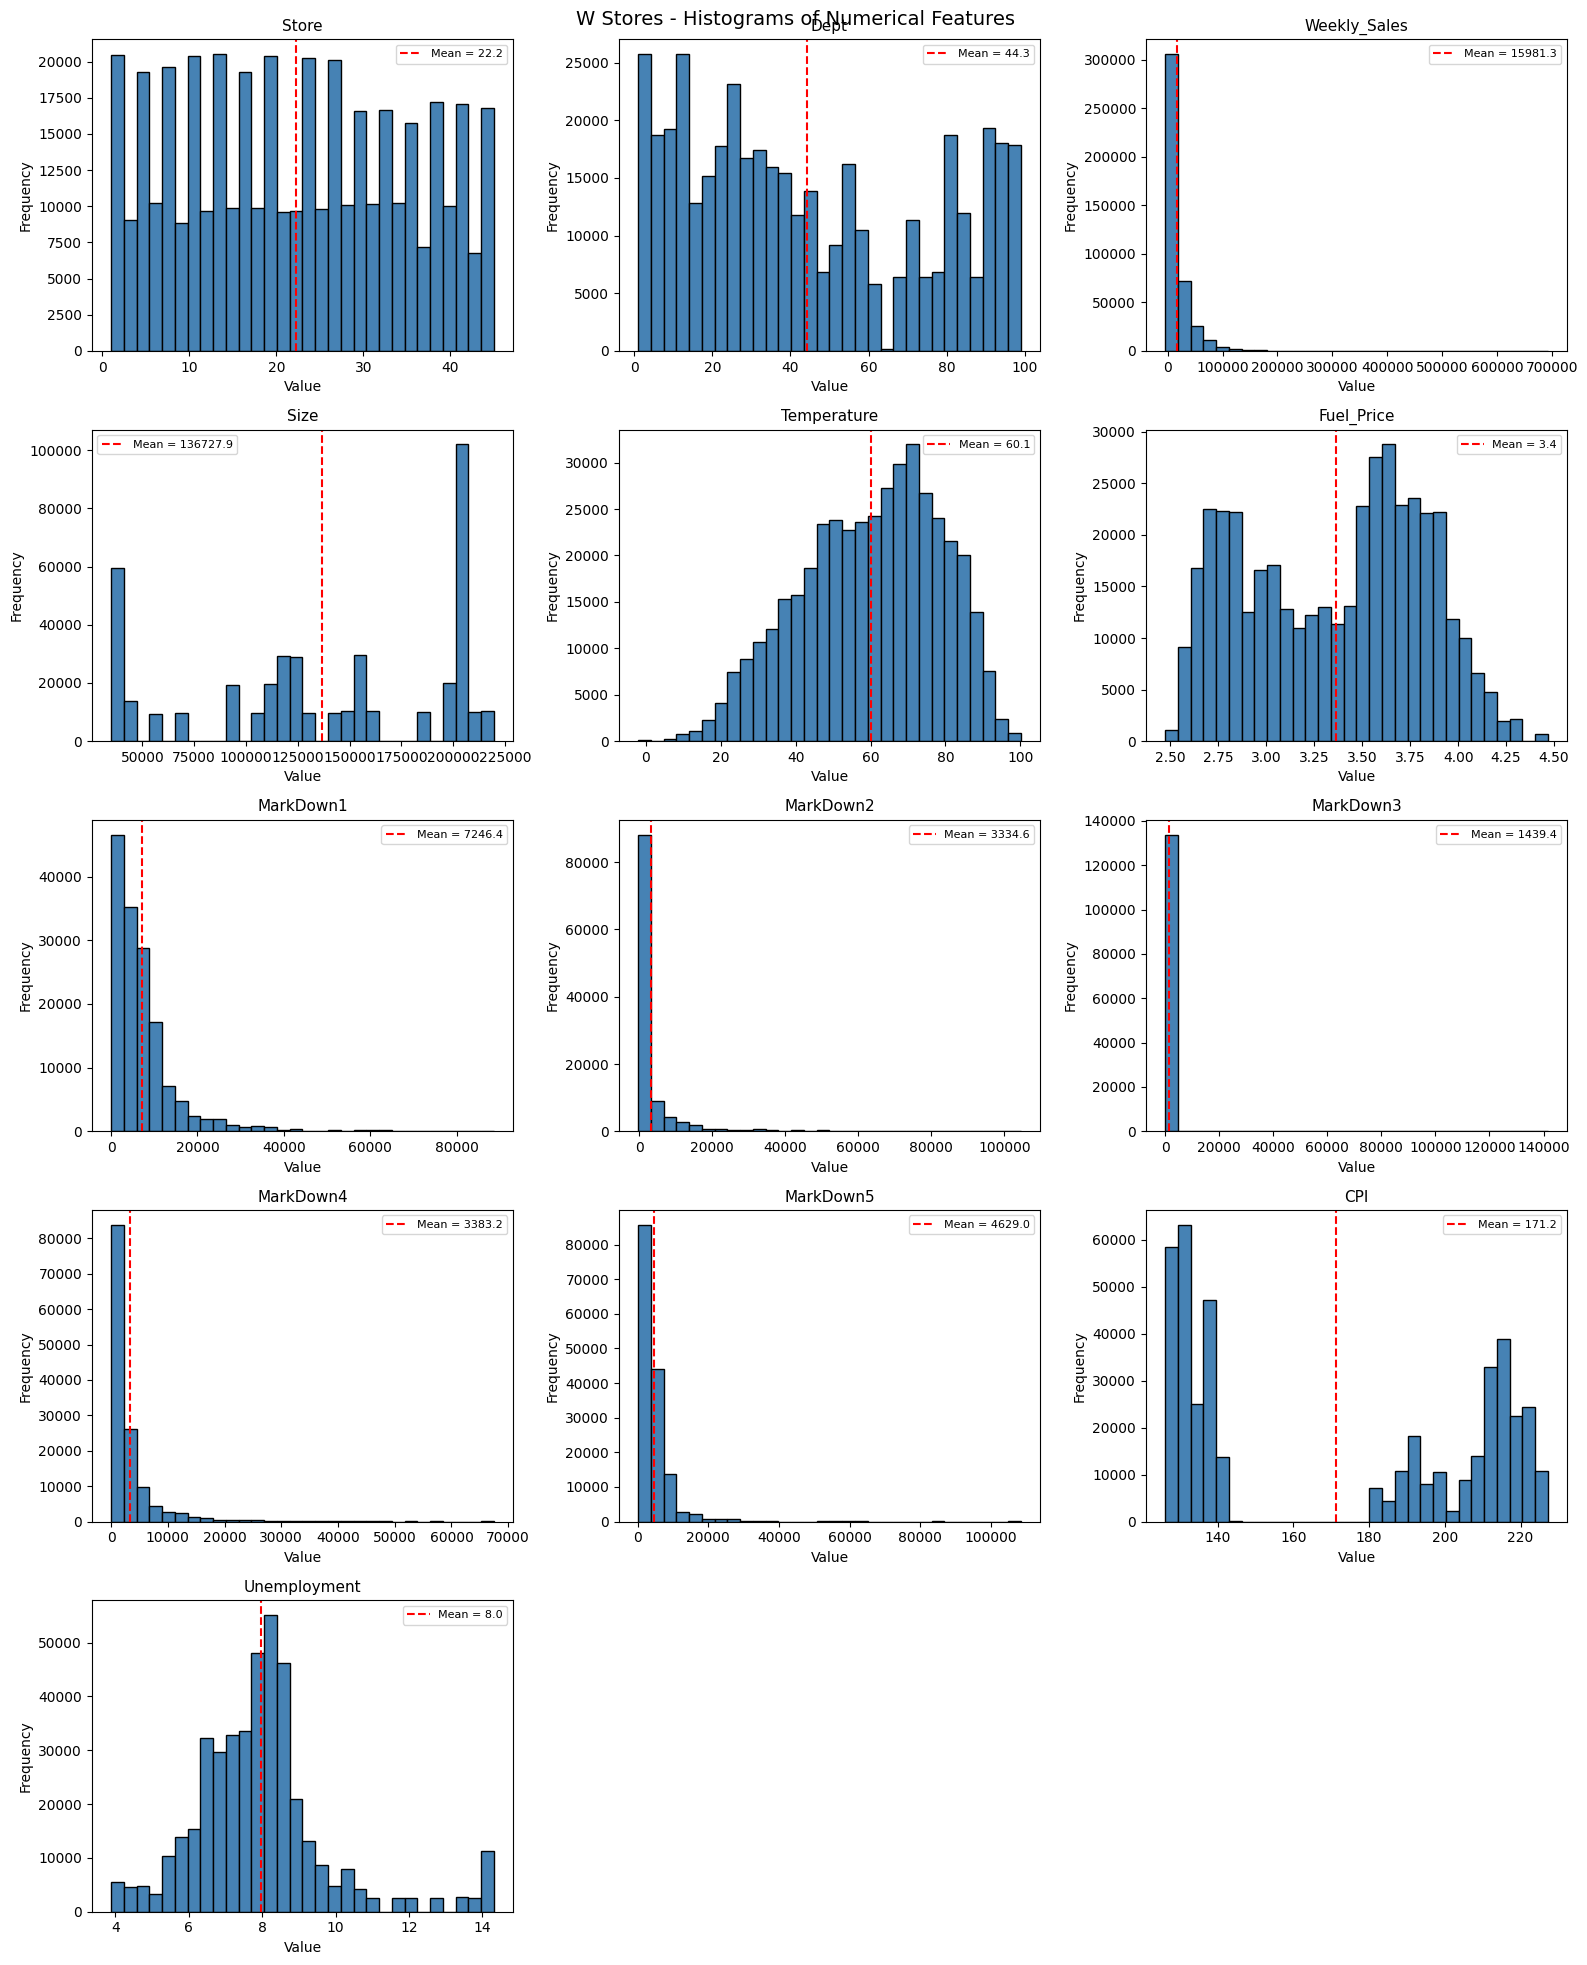

In [85]:
num_cols = w_df.select_dtypes(include='number').columns.tolist()
n     = len(num_cols)
ncols = 3
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(w_df[col].dropna(), bins=30,
                 color='steelblue', edgecolor='black')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    mean_val = w_df[col].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--',
                    linewidth=1.5, label=f'Mean = {mean_val:.1f}')
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('W Stores - Histograms of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

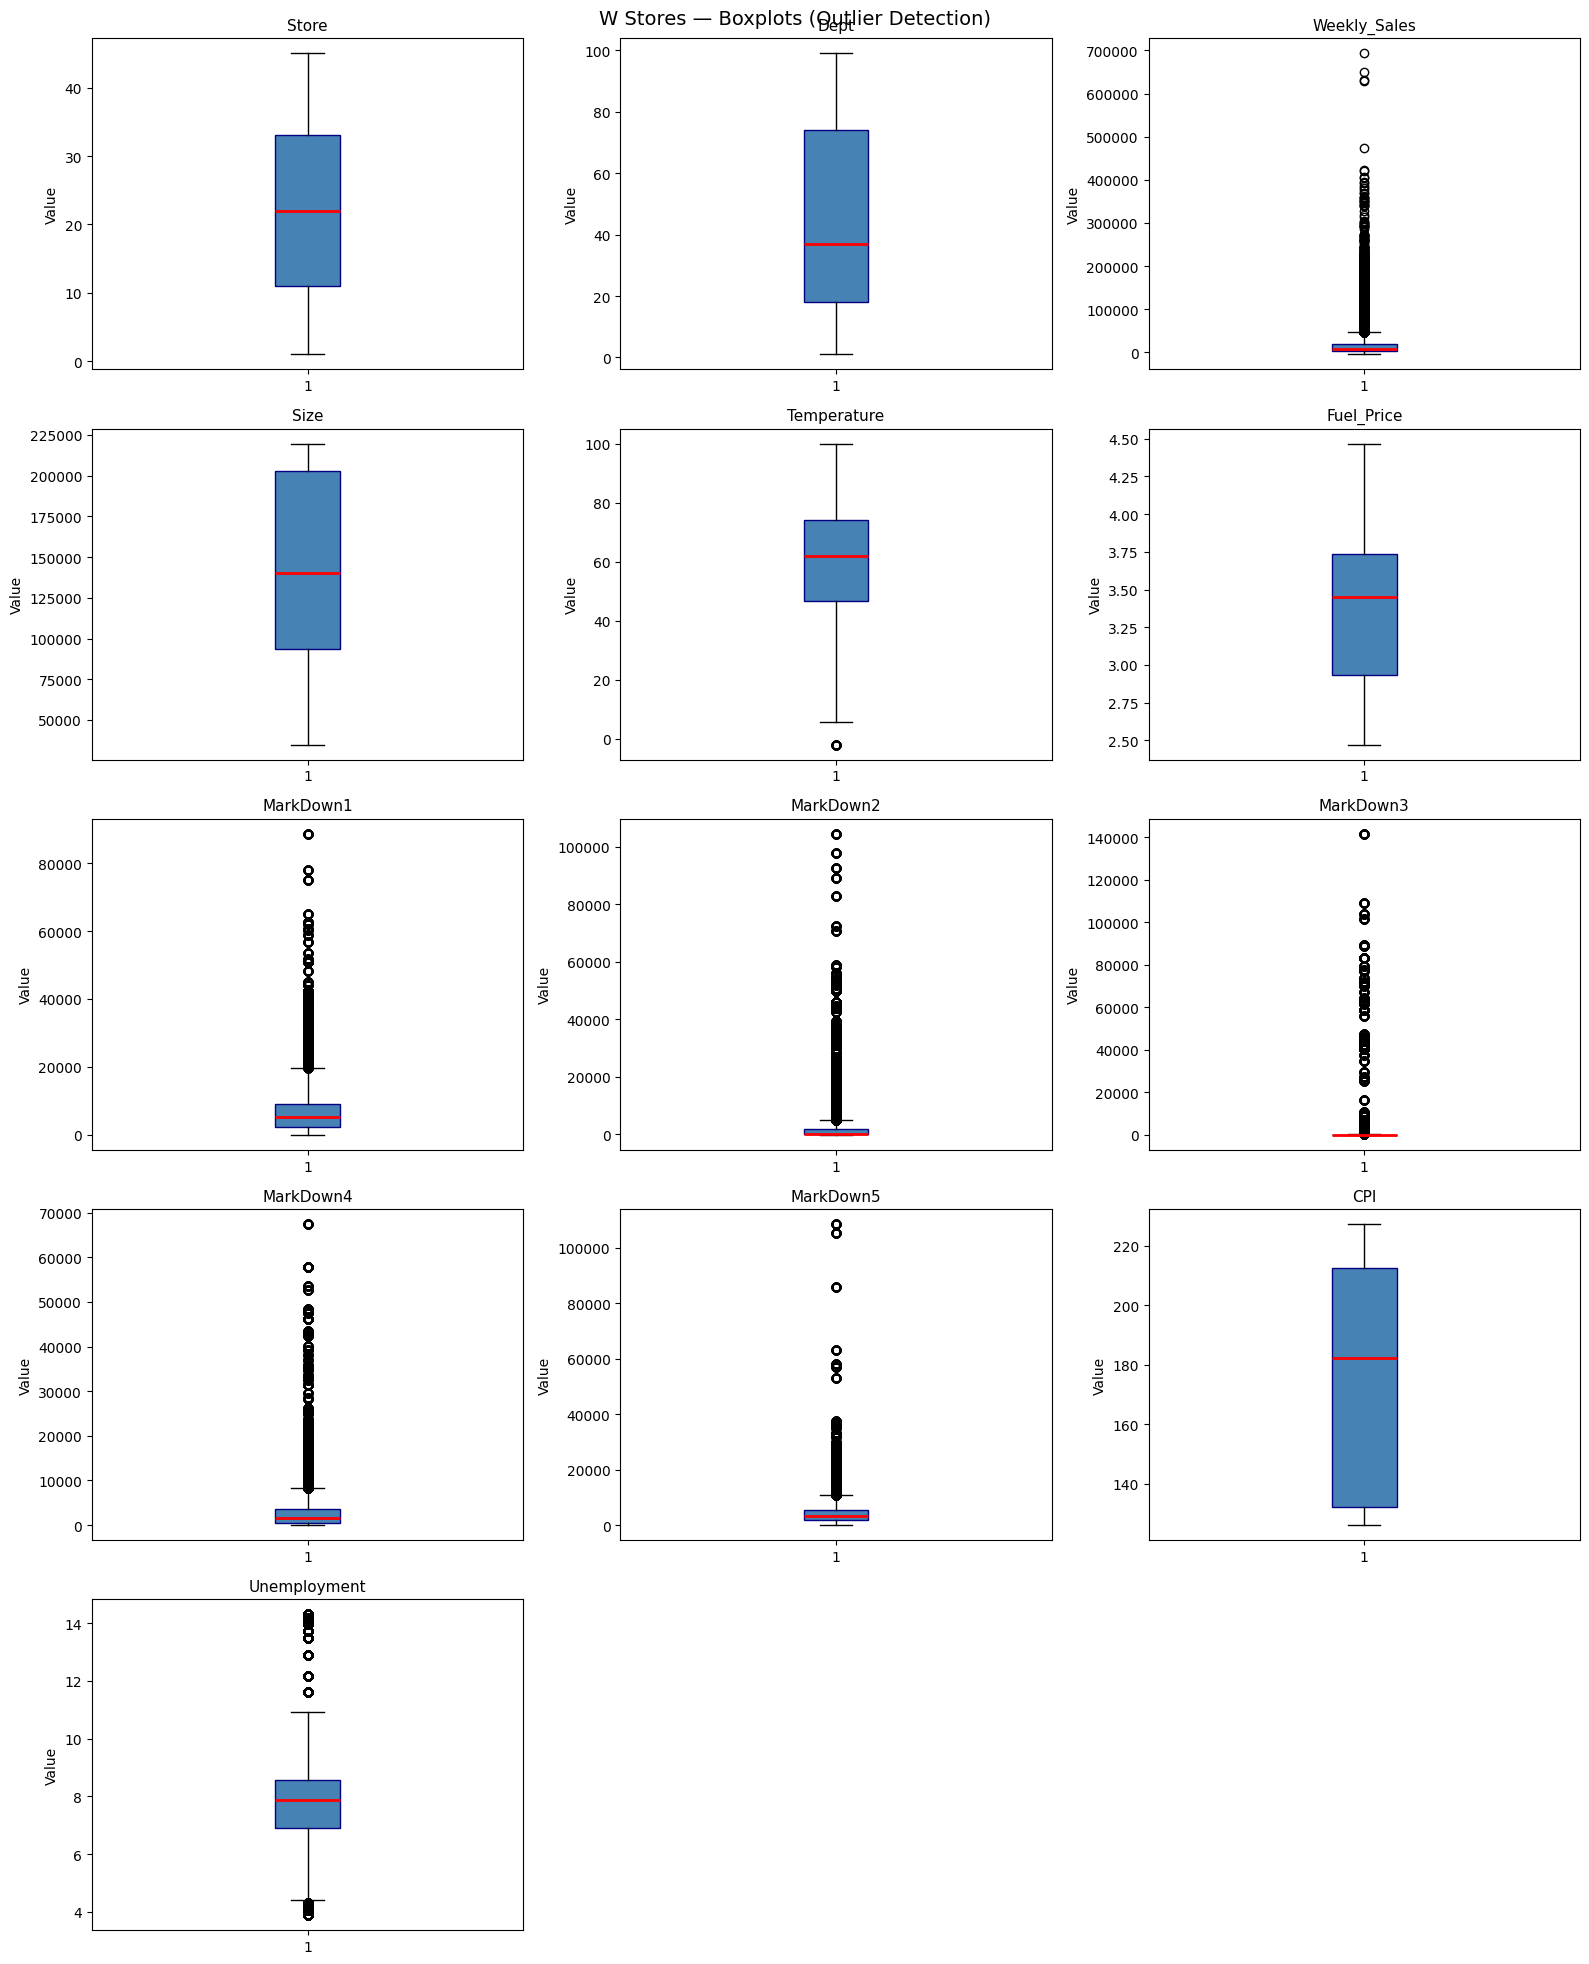

In [86]:
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(w_df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', color='navy'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Value')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('W Stores — Boxplots (Outlier Detection)', fontsize=14)
plt.tight_layout()
plt.show()

### Convert Data Types
Converting all data types to numerical. Since all values fed into a machine learning model must be numerical.
Non-numerical columns in W Stores are:
- **Date** - parsed to datetime, then converted into Year, Month, Week integer columns
- **Store Type** - Label Encoded from categorical (A, B, C) to integer (A=0, B=1, C=2)
- **IsHoliday** - from boolean to integer (False=0, True=1)

In [87]:
# Parse Date string to datetime
w_df['Date'] = pd.to_datetime(w_df['Date'])

# Extract integer features from the date
w_df['Year']  = w_df['Date'].dt.year
w_df['Month'] = w_df['Date'].dt.month
w_df['Week']  = w_df['Date'].dt.isocalendar().week.astype(int)

print("Date decomposed into Year, Month, Week:")
display(w_df[['Date', 'Year', 'Month', 'Week']].head(10))

Date decomposed into Year, Month, Week:


,Date,Year,Month,Week
0,2010-02-05,2010,2,5
1,2010-02-12,2010,2,6
2,2010-02-19,2010,2,7
3,2010-02-26,2010,2,8
4,2010-03-05,2010,3,9
5,2010-03-12,2010,3,10
6,2010-03-19,2010,3,11
7,2010-03-26,2010,3,12
8,2010-04-02,2010,4,13
9,2010-04-09,2010,4,14


In [88]:
le = LabelEncoder()

# Encode store Type: A → 0, B → 1, C → 2
# W Stores contains three store types: A, B, and C
w_df['Type_encoded'] = le.fit_transform(w_df['Type'])
print("Type encoding:")
for cls, code in zip(le.classes_, range(len(le.classes_))):
    print(f"  {cls} → {code}")

# IsHoliday: True → 1, False → 0
# After merge there may be IsHoliday_x and IsHoliday_y — use _x (from sales.csv)
holiday_col = 'IsHoliday_x' if 'IsHoliday_x' in w_df.columns else 'IsHoliday'
w_df['IsHoliday_encoded'] = w_df[holiday_col].astype(int)

print(f"\nIsHoliday encoded (using '{holiday_col}'):")
display(w_df[['Store', 'Date', holiday_col, 'IsHoliday_encoded']].head(10))

Type encoding:
  A → 0
  B → 1
  C → 2

IsHoliday encoded (using 'IsHoliday_x'):


,Store,Date,IsHoliday_x,IsHoliday_encoded
0,1,2010-02-05,False,0
1,1,2010-02-12,True,1
2,1,2010-02-19,False,0
3,1,2010-02-26,False,0
4,1,2010-03-05,False,0
5,1,2010-03-12,False,0
6,1,2010-03-19,False,0
7,1,2010-03-26,False,0
8,1,2010-04-02,False,0
9,1,2010-04-09,False,0


## 2. Visualize Data
Focusing on visualizing the **converted columns** (Date decomposed into Year/Month/Week,
Type encoded, IsHoliday encoded) along with Weekly_Sales trends.
Columns that were already numerical and plotted in Task 1 are not repeated in this clean data section.

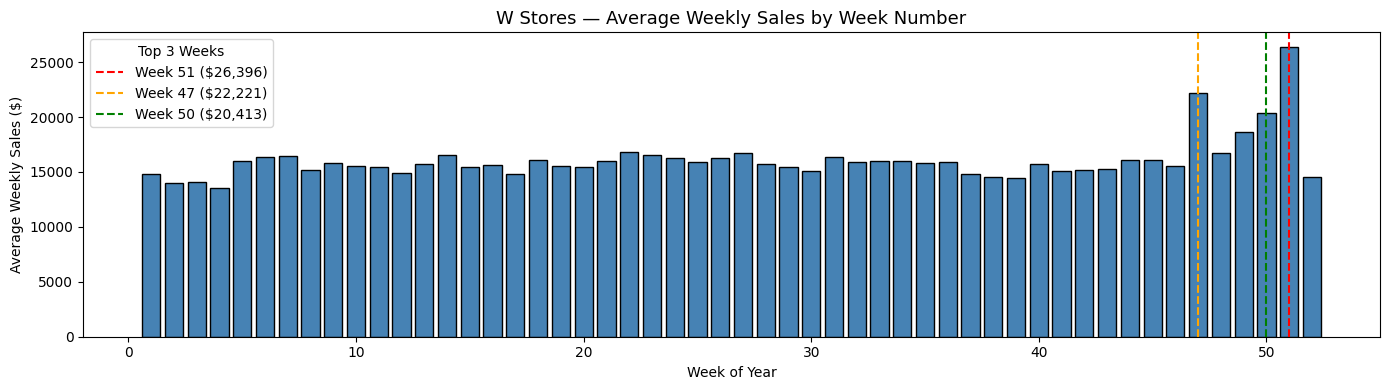

Peak sales week: Week 51 with average $26,396

Top 3 weeks by average sales:
  Week 51: $26,396
  Week 47: $22,221
  Week 50: $20,413


In [89]:
# Week was extracted from Date - show which weeks of the year drive highest sales
weekly_avg = w_df.groupby('Week')['Weekly_Sales'].mean()

# Find the actual peak week and top 3 weeks from the data
peak_week      = weekly_avg.idxmax()
peak_sales     = weekly_avg.max()
top3_weeks     = weekly_avg.nlargest(3)

plt.figure(figsize=(14, 4))
plt.bar(weekly_avg.index, weekly_avg.values, color='steelblue', edgecolor='black')
plt.title('W Stores — Average Weekly Sales by Week Number', fontsize=13)
plt.xlabel('Week of Year')
plt.ylabel('Average Weekly Sales ($)')

# Top 3 weeks from the data
colors_top = ['red', 'orange', 'green']
for i, (week, val) in enumerate(top3_weeks.items()):
    plt.axvline(x=week, color=colors_top[i], linestyle='--',
                linewidth=1.5, label=f'Week {week} (${val:,.0f})')

plt.legend(title='Top 3 Weeks')
plt.tight_layout()
plt.show()

print(f"Peak sales week: Week {peak_week} with average ${peak_sales:,.0f}")
print(f"\nTop 3 weeks by average sales:")
for week, val in top3_weeks.items():
    print(f"  Week {week}: ${val:,.0f}")

IsHoliday class distribution:


,Label,Count,Percentage
0,Non-Holiday,390722,93.0
1,Holiday,29563,7.0


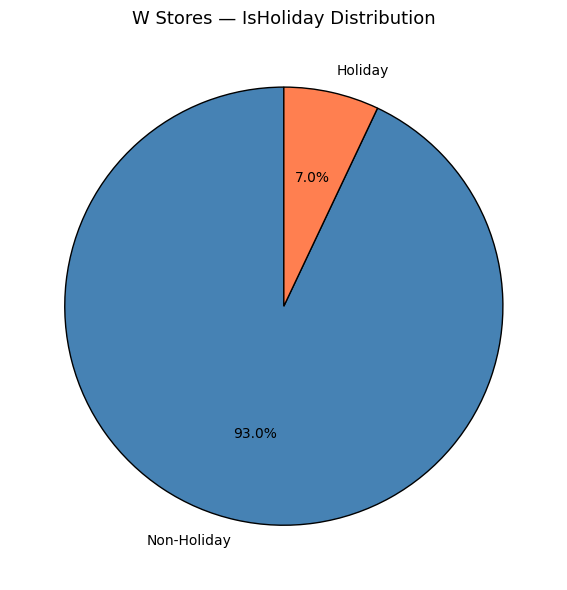

In [90]:
print("IsHoliday class distribution:")
summary = pd.DataFrame({
    'Label'      : ['Non-Holiday', 'Holiday'],
    'Count'      : holiday_counts.values,
    'Percentage' : holiday_pct.round(1).values
})
display(summary)

# Pie chart showing proportion of holiday vs non-holiday weeks
plt.figure(figsize=(6, 6))
plt.pie(holiday_counts.values,
        labels=['Non-Holiday', 'Holiday'],
        colors=['steelblue', 'coral'],
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops=dict(edgecolor='black'))
plt.title('W Stores — IsHoliday Distribution', fontsize=13)
plt.tight_layout()
plt.show()

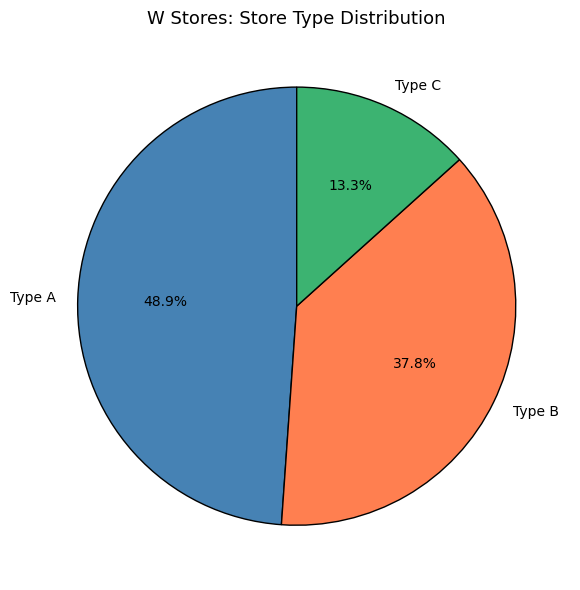

In [91]:
# Pie chart showing proportion of store types
store_types = w_df.drop_duplicates('Store')[['Store', 'Type_encoded']].copy()
type_map = {0: 'Type A', 1: 'Type B', 2: 'Type C'}
store_types['Type_Label'] = store_types['Type_encoded'].map(type_map)
type_counts = store_types['Type_Label'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(type_counts.values,
        labels=type_counts.index,
        colors=['steelblue', 'coral', 'mediumseagreen'],
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops=dict(edgecolor='black'))
plt.title('W Stores: Store Type Distribution', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Clean data
The following cleaning steps are applied to the W Stores dataset:
1. **Missing values** - MarkDown1–5 have 64–73% missing, imputed with 0
2. **Outliers** - Weekly_Sales has extreme values, capped using IQR Winsorisation
3. **Imbalanced data** - IsHoliday is heavily skewed (~93% non-holiday), noted as limitation
4. **Feature selection** - Drop redundant or low-value columns
5. **Standardisation** - Scale all features to mean=0, std=1

### Handle Missing Values
MarkDown1–5 represent promotional markdowns. They are missing for 64–73% of weeks
because promotions were not always active. We replace missing values NaN with 0 to indicate no promotion was active that week, rather than dropping rows and losing 64–73% of data.

In [92]:
markdown_cols = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']

print("Missing values BEFORE imputation:")
for col in markdown_cols:
    pct = w_df[col].isnull().mean() * 100
    print(f"  {col}: {w_df[col].isnull().sum():,} missing ({pct:.1f}%)")

# Fill with 0 - missing MarkDown means no promotion was active that week
w_df[markdown_cols] = w_df[markdown_cols].fillna(0)

print("\nMissing values AFTER imputation:")
for col in markdown_cols:
    print(f"  {col}: {w_df[col].isnull().sum()} missing")

Missing values BEFORE imputation:
  MarkDown1: 270,889 missing (64.3%)
  MarkDown2: 310,322 missing (73.6%)
  MarkDown3: 284,479 missing (67.5%)
  MarkDown4: 286,603 missing (68.0%)
  MarkDown5: 270,138 missing (64.1%)

Missing values AFTER imputation:
  MarkDown1: 0 missing
  MarkDown2: 0 missing
  MarkDown3: 0 missing
  MarkDown4: 0 missing
  MarkDown5: 0 missing


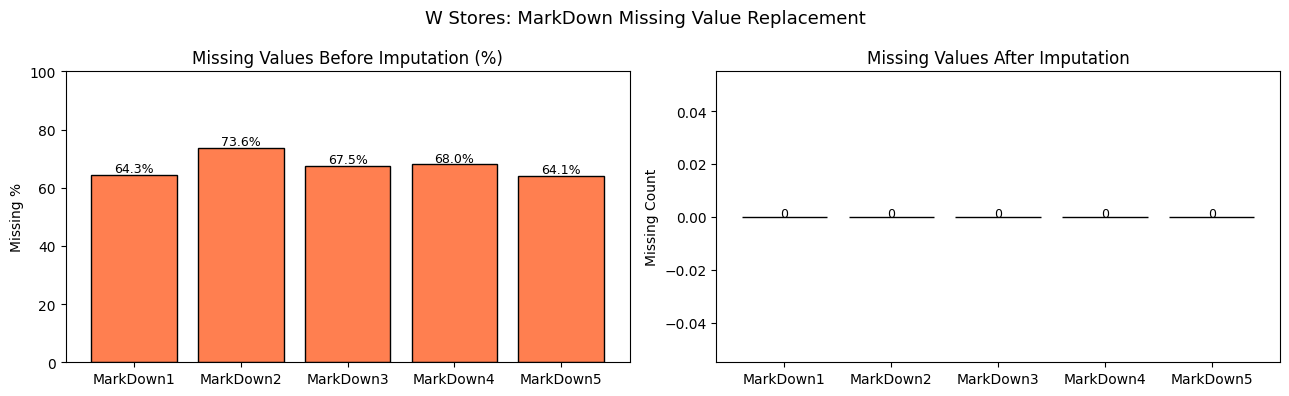

In [93]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Before
missing_before = [64.3, 73.6, 67.5, 68.0, 64.1]
axes[0].bar(markdown_cols, missing_before,
            color='coral', edgecolor='black')
axes[0].set_title('Missing Values Before Imputation (%)', fontsize=12)
axes[0].set_ylabel('Missing %')
axes[0].set_ylim(0, 100)
for i, v in enumerate(missing_before):
    axes[0].text(i, v + 1, f'{v}%', ha='center', fontsize=9)

# After
missing_after = [w_df[col].isnull().sum() for col in markdown_cols]
axes[1].bar(markdown_cols, missing_after,
            color='mediumseagreen', edgecolor='black')
axes[1].set_title('Missing Values After Imputation', fontsize=12)
axes[1].set_ylabel('Missing Count')
for i, v in enumerate(missing_after):
    axes[1].text(i, v, f'{v}', ha='center', fontsize=9)

plt.suptitle('W Stores: MarkDown Missing Value Replacement', fontsize=13)
plt.tight_layout()
plt.show()

### Handling Outliers
Weekly_Sales contains extreme high values. Instead of dropping rows, we use
IQR Winsorisation (capping) to retain all 421,570 rows while reducing distortion.

Negative Weekly_Sales values found : 1,285
Total rows before                  : 421,570
Percentage of data affected        : 0.3%

Upper fence (IQR)                  : $47,395.16
No extreme high outliers found beyond upper fence.

Rows after dropping negatives      : 420,285
Reasoning: Negative sales represent returns exceeding gross sales.
At only 0.3% of data, dropping is cleaner than capping to 0.


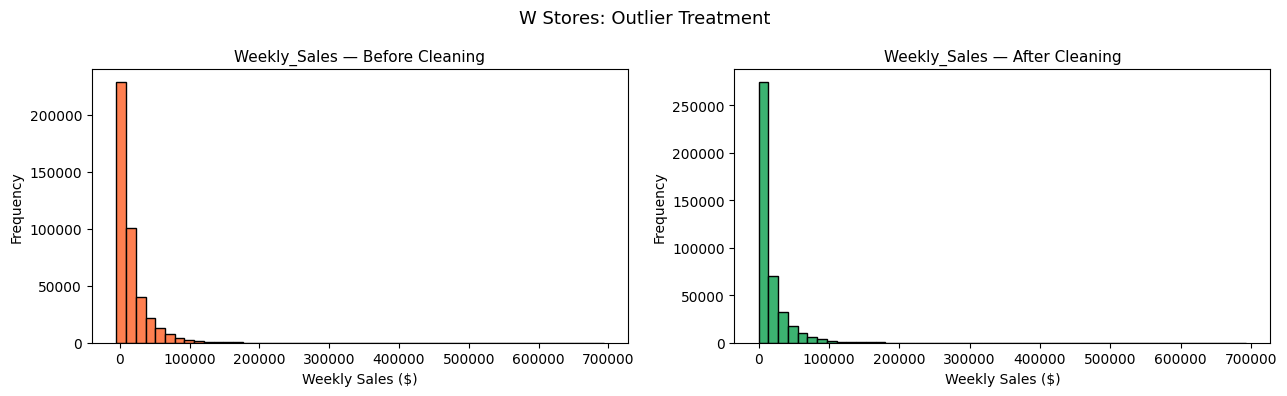


Final range: $0.00 — $693,099.36


In [94]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Before dropping
axes[0].hist(w_df['Weekly_Sales'], bins=50,
             color='coral', edgecolor='black')
axes[0].set_title('Weekly_Sales — Before Cleaning', fontsize=11)
axes[0].set_xlabel('Weekly Sales ($)')
axes[0].set_ylabel('Frequency')

# Calculate IQR fences
Q1    = w_df['Weekly_Sales'].quantile(0.25)
Q3    = w_df['Weekly_Sales'].quantile(0.75)
IQR   = Q3 - Q1
upper = Q3 + 1.5 * IQR

# Count negatives
neg_sales = (w_df['Weekly_Sales'] < 0).sum()
print(f"Negative Weekly_Sales values found : {neg_sales:,}")
print(f"Total rows before                  : {len(w_df):,}")
print(f"Percentage of data affected        : {neg_sales/len(w_df)*100:.1f}%")
print(f"\nUpper fence (IQR)                  : ${upper:,.2f}")
print("No extreme high outliers found beyond upper fence.")

# Drop negative rows - only 0.3% of data loss
w_df = w_df[w_df['Weekly_Sales'] >= 0].reset_index(drop=True)
print(f"\nRows after dropping negatives      : {len(w_df):,}")
print("Reasoning: Negative sales represent returns exceeding gross sales.")
print("At only 0.3% of data, dropping is cleaner than capping to 0.")

# After dropping
axes[1].hist(w_df['Weekly_Sales'], bins=50,
             color='mediumseagreen', edgecolor='black')
axes[1].set_title('Weekly_Sales — After Cleaning', fontsize=11)
axes[1].set_xlabel('Weekly Sales ($)')
axes[1].set_ylabel('Frequency')

plt.suptitle('W Stores: Outlier Treatment', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nFinal range: ${w_df['Weekly_Sales'].min():,.2f} — ${w_df['Weekly_Sales'].max():,.2f}")

### Standardisation
All input features are scaled to mean=0 and std=1 using StandardScaler.

This is important because features have very different scales:
- Size can be in the tens of thousands
- IsHoliday_encoded is only 0 or 1
- Without scaling, larger-scale features would dominate model training

The target variable **Weekly_Sales is NOT scaled** as we need its
original values for meaningful predictions.

In [95]:
from sklearn.preprocessing import StandardScaler

target       = 'Weekly_Sales'
feature_cols = [c for c in w_df.select_dtypes(include='number').columns
                if c != target]

scaler = StandardScaler()
w_df[feature_cols] = scaler.fit_transform(w_df[feature_cols])

print(f"Standardised {len(feature_cols)} features:")
print(f"{feature_cols}\n")

print("Verifying mean ≈ 0 and std ≈ 1:")
display(w_df[feature_cols].describe().round(3))

print("\nWeekly_Sales (target) — NOT scaled:")
print(f"  Min : ${w_df[target].min():,.2f}")
print(f"  Max : ${w_df[target].max():,.2f}")
print(f"  Mean: ${w_df[target].mean():,.2f}")

Standardised 17 features:
['Store', 'Dept', 'Size', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Year', 'Month', 'Week', 'Type_encoded', 'IsHoliday_encoded']

Verifying mean ≈ 0 and std ≈ 1:


,Store,Dept,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month,Week,Type_encoded,IsHoliday_encoded
count,420285.000,420285.000,420285.000,420285.000,420285.000,420285.000,420285.000,420285.000,420285.000,420285.000,420285.000,420285.000,420285.000,420285.000,420285.000,420285.000,420285.000
mean,-0.000,0.000,-0.000,-0.000,0.000,-0.000,-0.000,0.000,0.000,0.000,0.000,0.000,-0.000,0.000,-0.000,0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-1.658,-1.417,-1.670,-3.369,-1.939,-0.428,-0.225,-0.090,-0.278,-0.395,-1.153,-2.190,-1.215,-1.680,-1.754,-0.885,-0.275
25%,-0.876,-0.860,-0.707,-0.727,-0.933,-0.428,-0.173,-0.085,-0.278,-0.395,-1.001,-0.574,-1.215,-0.755,-0.836,-0.885,-0.275
50%,-0.015,-0.237,0.056,0.108,0.199,-0.428,-0.173,-0.085,-0.278,-0.395,0.284,-0.050,0.040,-0.139,0.012,-0.885,-0.275
75%,0.845,0.975,1.078,0.769,0.822,0.035,-0.173,-0.084,-0.169,0.120,1.053,0.326,1.294,0.786,0.860,0.616,-0.275
max,1.783,1.795,1.359,2.171,2.415,14.217,20.416,25.510,17.042,25.406,1.430,3.408,1.294,1.711,1.849,2.117,3.635



Weekly_Sales (target) — NOT scaled:
  Min : $0.00
  Max : $693,099.36
  Mean: $16,030.33


### Feature Selection
We drop columns that are redundant or were created for plotting purposes only.
All remaining columns carry meaningful predictive value for Weekly_Sales.

In [96]:
# Drop columns not needed for modelling
drop_these = [c for c in ['Date', 'Type', 'IsHoliday_x', 'IsHoliday_y',
                           'YearMonth', 'Type_Label'] if c in w_df.columns]
w_df.drop(columns=drop_these, inplace=True)
print(f"Dropped: {drop_these}")

Dropped: ['Date', 'Type', 'IsHoliday_x', 'IsHoliday_y']


In [97]:
selected_features = {
    'Store'            : 'Individual store identity affects sales patterns',
    'Dept'             : 'Department drives significant sales variation',
    'Weekly_Sales'     : 'Target variable — what we are predicting',
    'Type_encoded'     : 'Store type (A/B/C) strongly influences sales volume',
    'Size'             : 'Larger stores generate higher sales',
    'Temperature'      : 'Weather conditions affect shopping behaviour',
    'Fuel_Price'       : 'Fuel cost affects consumer spending patterns',
    'MarkDown1'        : 'Promotional activity directly impacts sales',
    'MarkDown2'        : 'Promotional activity directly impacts sales',
    'MarkDown3'        : 'Promotional activity directly impacts sales',
    'MarkDown4'        : 'Promotional activity directly impacts sales',
    'MarkDown5'        : 'Promotional activity directly impacts sales',
    'CPI'              : 'Consumer Price Index reflects economic conditions',
    'Unemployment'     : 'Employment rate affects consumer spending power',
    'IsHoliday_encoded': 'Holiday weeks show higher average sales',
    'Year'             : 'Captures year-over-year growth trends',
    'Month'            : 'Captures monthly seasonality',
    'Week'             : 'Captures weekly seasonality within the year',
}

print(f"Final feature set: {w_df.shape[1]} columns, {w_df.shape[0]:,} rows\n")
print("Features kept:")
for col, reason in selected_features.items():
    if col in w_df.columns:
        print(f"  {col:22s} — {reason}")

Final feature set: 18 columns, 420,285 rows

Features kept:
  Store                  — Individual store identity affects sales patterns
  Dept                   — Department drives significant sales variation
  Weekly_Sales           — Target variable — what we are predicting
  Type_encoded           — Store type (A/B/C) strongly influences sales volume
  Size                   — Larger stores generate higher sales
  Temperature            — Weather conditions affect shopping behaviour
  Fuel_Price             — Fuel cost affects consumer spending patterns
  MarkDown1              — Promotional activity directly impacts sales
  MarkDown2              — Promotional activity directly impacts sales
  MarkDown3              — Promotional activity directly impacts sales
  MarkDown4              — Promotional activity directly impacts sales
  MarkDown5              — Promotional activity directly impacts sales
  CPI                    — Consumer Price Index reflects economic conditions
  Une

In [98]:
print(f"Final feature set: {w_df.shape[1]} columns, {w_df.shape[0]:,} rows\n")
display(w_df.head(10))

Final feature set: 18 columns, 420,285 rows



,Store,Dept,Weekly_Sales,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month,Week,Type_encoded,IsHoliday_encoded
0,-1.657554,-1.417463,24924.50,0.238806,-0.963803,-1.720502,-0.427903,-0.173111,-0.084714,-0.278111,-0.395323,1.018435,0.078290,-1.215275,-1.371932,-1.471672,-0.884616,-0.275068
1,-1.657554,-1.417463,46039.49,0.238806,-1.169785,-1.772844,-0.427903,-0.173111,-0.084714,-0.278111,-0.395323,1.022159,0.078290,-1.215275,-1.371932,-1.401013,-0.884616,3.635463
2,-1.657554,-1.417463,41595.55,0.238806,-1.092813,-1.846995,-0.427903,-0.173111,-0.084714,-0.278111,-0.395323,1.023358,0.078290,-1.215275,-1.371932,-1.330354,-0.884616,-0.275068
3,-1.657554,-1.417463,19403.54,0.238806,-0.729635,-1.744492,-0.427903,-0.173111,-0.084714,-0.278111,-0.395323,1.024137,0.078290,-1.215275,-1.371932,-1.259694,-0.884616,-0.275068
4,-1.657554,-1.417463,21827.90,0.238806,-0.736681,-1.604913,-0.427903,-0.173111,-0.084714,-0.278111,-0.395323,1.024916,0.078290,-1.215275,-1.063612,-1.189035,-0.884616,-0.275068
5,-1.657554,-1.417463,21043.39,0.238806,-0.124699,-1.513314,-0.427903,-0.173111,-0.084714,-0.278111,-0.395323,1.025695,0.078290,-1.215275,-1.063612,-1.118376,-0.884616,-0.275068
6,-1.657554,-1.417463,22136.64,0.238806,-0.298699,-1.397726,-0.427903,-0.173111,-0.084714,-0.278111,-0.395323,1.021481,0.078290,-1.215275,-1.063612,-1.047716,-0.884616,-0.275068
7,-1.657554,-1.417463,26229.21,0.238806,-0.468363,-1.371555,-0.427903,-0.173111,-0.084714,-0.278111,-0.395323,1.016436,0.078290,-1.215275,-1.063612,-0.977057,-0.884616,-0.275068
8,-1.657554,-1.417463,57258.43,0.238806,0.118143,-1.399907,-0.427903,-0.173111,-0.084714,-0.278111,-0.395323,1.011390,-0.081592,-1.215275,-0.755293,-0.906398,-0.884616,-0.275068
9,-1.657554,-1.417463,42960.91,0.238806,0.312741,-1.288680,-0.427903,-0.173111,-0.084714,-0.278111,-0.395323,1.006345,-0.081592,-1.215275,-0.755293,-0.835739,-0.884616,-0.275068


## 4. Identify correlated variables

We compute the Pearson correlation matrix for all numerical features and
visualise it as a heatmap. This helps us identify:
- Which features are strongly related to Weekly_Sales (our target)
- Which features are highly correlated with each other (multicollinearity)

Pairs with |r| > 0.9 are considered highly correlated and one from each
pair will be dropped to reduce redundancy.

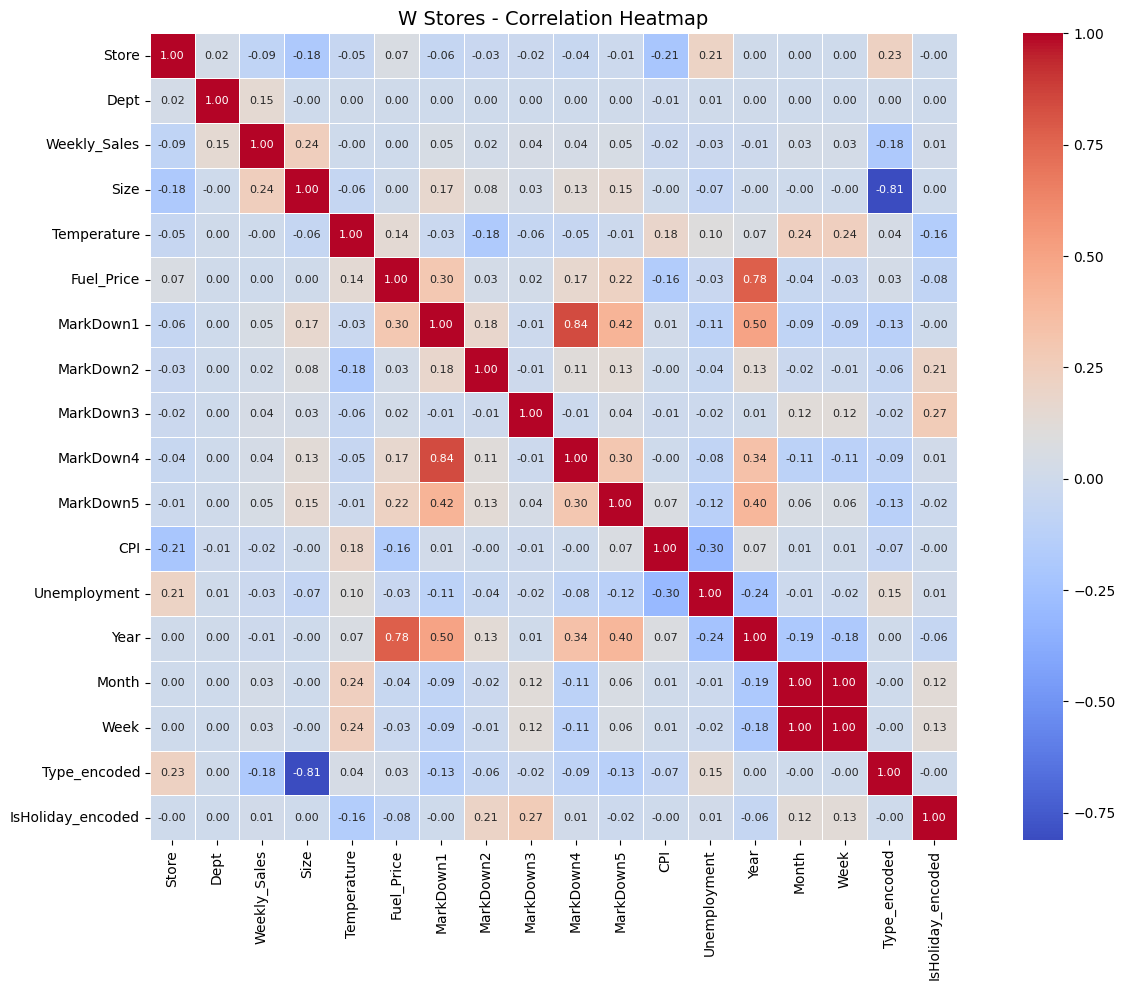

In [99]:
corr = w_df.select_dtypes(include='number').corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True, annot_kws={"size": 8})
plt.title('W Stores - Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

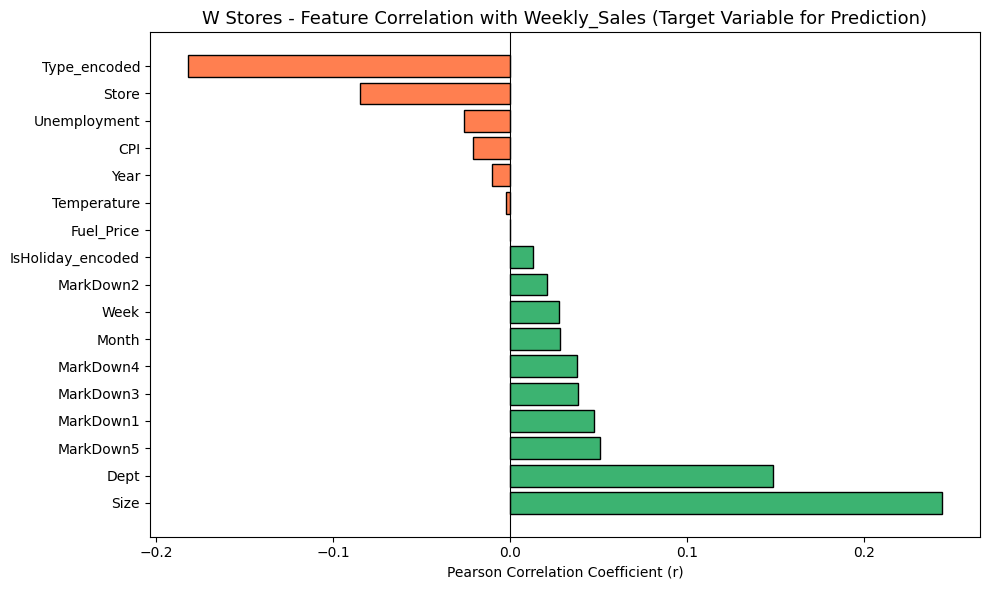

Feature correlations with Weekly_Sales (sorted):
  Size                   : +0.244
  Dept                   : +0.149
  MarkDown5              : +0.051
  MarkDown1              : +0.047
  MarkDown3              : +0.039
  MarkDown4              : +0.037
  Month                  : +0.028
  Week                   : +0.028
  MarkDown2              : +0.021
  IsHoliday_encoded      : +0.013
  Fuel_Price             : +0.000
  Temperature            : -0.002
  Year                   : -0.010
  CPI                    : -0.021
  Unemployment           : -0.026
  Store                  : -0.085
  Type_encoded           : -0.182


In [100]:
target_corr = corr['Weekly_Sales'].drop('Weekly_Sales').sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = ['mediumseagreen' if v > 0 else 'coral' for v in target_corr.values]
plt.barh(target_corr.index, target_corr.values,
         color=colors, edgecolor='black')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('W Stores - Feature Correlation with Weekly_Sales (Target Variable for Prediction)', fontsize=13)
plt.xlabel('Pearson Correlation Coefficient (r)')
plt.tight_layout()
plt.show()

print("Feature correlations with Weekly_Sales (sorted):")
for col, val in target_corr.items():
    print(f"  {col:22s} : {val:+.3f}")

In [101]:
# Drop Week : perfectly correlated with Month (r = 1.00)
# Keep Month : carries seasonal meaning shown in Task 2 visualisations

if 'Week' in w_df.columns:
    w_df.drop(columns=['Week'], inplace=True)
    print("Dropped: Week")
    print("Reasoning: Month vs Week r = 1.00 — perfect correlation.")
    print("           Week is redundant when Month is already present.")

print(f"\nFinal shape: {w_df.shape[0]:,} rows x {w_df.shape[1]} columns")
print(f"Remaining columns: {list(w_df.columns)}")

Dropped: Week
Reasoning: Month vs Week r = 1.00 — perfect correlation.
           Week is redundant when Month is already present.

Final shape: 420,285 rows x 17 columns
Remaining columns: ['Store', 'Dept', 'Weekly_Sales', 'Size', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Year', 'Month', 'Type_encoded', 'IsHoliday_encoded']


In [102]:
# Drop near-zero correlation features
drop_low_corr = ['Fuel_Price', 'Temperature']
w_df.drop(columns=[c for c in drop_low_corr if c in w_df.columns], inplace=True)

print("Dropped low-correlation features:")
print("  Fuel_Price  (r = 0.000) — no linear relationship with Weekly_Sales")
print("  Temperature (r = -0.002) — no linear relationship with Weekly_Sales")
print(f"\nFinal shape: {w_df.shape[0]:,} rows x {w_df.shape[1]} columns")

Dropped low-correlation features:
  Fuel_Price  (r = 0.000) — no linear relationship with Weekly_Sales
  Temperature (r = -0.002) — no linear relationship with Weekly_Sales

Final shape: 420,285 rows x 15 columns


### Selected Features for Modelling

The following 14 features were selected as input variables for the model:

| # | Feature | Description |
|---|---|---|
| 1 | Store | Individual store identity |
| 2 | Dept | Department number |
| 3 | Size | Store size in square feet |
| 4 | MarkDown1 | Promotional markdown 1 |
| 5 | MarkDown2 | Promotional markdown 2 |
| 6 | MarkDown3 | Promotional markdown 3 |
| 7 | MarkDown4 | Promotional markdown 4 |
| 8 | MarkDown5 | Promotional markdown 5 |
| 9 | CPI | Consumer Price Index |
| 10 | Unemployment | Regional unemployment rate |
| 11 | Type_encoded | Store type (A=0, B=1, C=2) |
| 12 | IsHoliday_encoded | Holiday week flag (0/1) |
| 13 | Year | Year extracted from Date |
| 14 | Month | Month extracted from Date |

**Target variable:** `Weekly_Sales`

### Correlation Findings

**Features most correlated with Weekly_Sales:**
- `Size` (r = +0.24) — strongest positive correlation, larger stores generate more sales
- `Dept` (r = +0.15) — certain departments consistently outperform others
- `Type_encoded` (r = -0.18) — strongest negative correlation, higher encoded
  type values (B=1, C=2) are associated with lower sales than Type A (0)
- `Store` (r = -0.09) — mild negative, store identity has some influence

**Features dropped due to near-zero correlation with Weekly_Sales:**
- `Fuel_Price` (r = 0.00) — no linear relationship with sales, dropped
- `Temperature` (r = -0.002) — no linear relationship with sales, dropped
- `Week` (r = +0.028) — perfectly correlated with Month (r = 1.00), dropped

**Notable observation:**
- `IsHoliday_encoded` (r = +0.01) — surprisingly weak despite holiday weeks
  visually showing higher sales in Task 2. This is likely masked by the
  severe class imbalance (93% non-holiday vs 7% holiday). Feature is retained
  as it carries domain importance for retail sales prediction.

**Overall observation:**
Weekly_Sales shows weak individual correlations with most features (all below
|r| = 0.25). This suggests sales is driven by a combination of factors
rather than any single variable — making it a good candidate for a
multi-feature regression model.

**Highly correlated pair found:**
- `Month` vs `Week` (r = 1.00) — perfect correlation, `Week` is dropped
  as `Month` captures the same seasonality at a broader level

###Standardisation
All input features are scaled to mean=0 and std=1 using StandardScaler.

This is important because features have very different scales:
- Size can be in the tens of thousands
- IsHoliday_encoded is only 0 or 1
- Without scaling, larger-scale features would dominate model training

The target variable **Weekly_Sales is NOT scaled** as we need its
original values for meaningful predictions.

## Task 5: Summary

### Dataset
W Stores retail dataset comprising three CSV files (sales.csv, features.csv,
stores.csv) merged into a single DataFrame of 421,570 rows and 17 columns.
Target variable: **Weekly_Sales** (regression task).

### EDA Findings
- **Missing values**: MarkDown1–5 had 64–73% missing values, representing
  weeks where no promotions were active.
- **Seasonal trends**: Monthly aggregation revealed clear sales spikes in
  November–December each year, consistent with holiday shopping behaviour.
- **Store types**: Type A stores generated significantly higher average weekly
  sales than Types B and C, strongly linked to larger store size.
- **Holiday impact**: Holiday weeks showed higher average sales but represented
  only 7% of records (93% non-holiday), creating a class imbalance.
- **Outliers**: 1,285 negative Weekly_Sales values found (0.3% of data),
  representing weeks where customer returns exceeded gross sales.
- **Correlation**: Weekly_Sales showed weak individual correlations with all
  features (max r = 0.24 for Size), suggesting sales is driven by a
  combination of factors rather than any single variable.

### Preprocessing Steps

1. **Merging**: sales.csv, stores.csv, and features.csv merged on
   Store and Date into one DataFrame.

2. **Date conversion**: Date parsed from string to datetime and decomposed
   into Year, Month, and Week integer features.

3. **Encoding**:
   - Type label-encoded (A=0, B=1, C=2)
   - IsHoliday cast from boolean to integer (0/1)
   - Duplicate IsHoliday_y dropped after merge

4. **Missing values**: MarkDown1–5 NaNs replaced with 0, absence of
   a markdown entry indicates no promotion was active that week.

5. **Outliers**: 1,285 negative Weekly_Sales rows dropped (0.3% of data).
   Dropping preferred over capping as the volume was negligible.

6. **Imbalanced data**: IsHoliday imbalance (93/7) noted as a limitation.
   Oversampling not applied as this is a regression task, IsHoliday
   is an input feature, not the prediction label.

7. **Feature selection**:
   - Week dropped (r = 1.00 with Month, perfectly redundant)
   - Fuel_Price dropped (r = 0.00 with Weekly_Sales)
   - Temperature dropped (r = -0.002 with Weekly_Sales)

8. **Standardisation**: All 14 input features scaled to mean=0, std=1
   using StandardScaler. Weekly_Sales (target) left unscaled.

### Final Dataset
- **Rows**: 420,285
- **Features**: 14 input variables + 1 target (Weekly_Sales)
- **Selected features**: Store, Dept, Size, MarkDown1–5, CPI,
  Unemployment, Type_encoded, IsHoliday_encoded, Year, Month